<a href="https://colab.research.google.com/github/SagidAI/Breast-Cancer-Classification/blob/main/Breast_Cancer_Classification_using_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Name: Breast Cancer Prediction.

Model: Logistic Regression.

Accuracy: 97.37%

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# 1. Load Data
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [ ]:
# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Data Normalization to ensure all features contribute equally.

In [ ]:
# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
# 5. Prediction
y_pred = model.predict(X_test_scaled)

### Evaluating the model performance using Confusion Matrix.

In [ ]:
# 6. Final Results
print(f"Final Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final Accuracy: 97.37%

Confusion Matrix:
[[41  2]
 [ 1 70]]


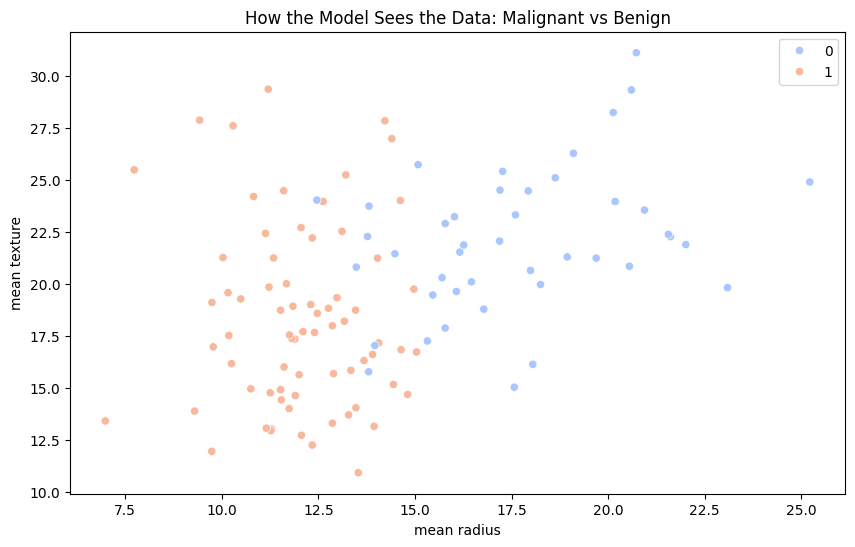

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['mean radius'], y=X_test['mean texture'], hue=y_test, palette='coolwarm')
plt.title('How the Model Sees the Data: Malignant vs Benign')
plt.show()

In [ ]:
def predict_new_case(data_input):
    scaled_input = scaler.transform(pd.DataFrame([data_input], columns=data.feature_names))
    prediction = model.predict(scaled_input)
    return "Malignant" if prediction[0] == 0 else "Benign"

print(predict_new_case(X_test.iloc[0]))

Benign
